In [1]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv('fatal-police-shootings-data.csv')

In [7]:
df

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,2015-01-02,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,2015-01-02,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,2015-01-03,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,2015-01-04,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,2015-01-04,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5411,5921,William Slyter,2020-06-13,shot,gun,22.0,M,W,Kansas City,MO,False,other,Other,False
5412,5922,TK TK,2020-06-13,shot,undetermined,NaN,M,NaN,San Bernardino,CA,False,attack,Not fleeing,False
5413,5924,Nicholas Hirsh,2020-06-15,shot,gun,31.0,M,W,Lawrence,KS,False,attack,Car,False
5414,5926,TK TK,2020-06-16,shot,gun,24.0,M,NaN,Beach Park,IL,False,attack,Not fleeing,False


In [9]:
pivot_1 = df.pivot_table(
    values='id',
    index='race',
    columns='signs_of_mental_illness',
    aggfunc='count'
)

In [10]:
pivot_1

signs_of_mental_illness,False,True
race,,
A,69,24
B,1114,184
H,745,157
N,64,14
O,37,11
W,1763,713


In [13]:
pivot_2 = df.pivot_table(
    values='id',
    index='race',
    columns='signs_of_mental_illness',
    aggfunc='count',
)   #mozna dodac .fillna(0)

In [16]:
pivot_2['total'] = pivot_2.sum(axis=1)

In [17]:
pivot_2

signs_of_mental_illness,False,True,total
race,,,
A,69,24,93
B,1114,184,1298
H,745,157,902
N,64,14,78
O,37,11,48
W,1763,713,2476


In [21]:
pivot_2['mental_illness_%'] = (
    pivot_2[True] / pivot_2['total']
) * 100

In [19]:
pivot_2

signs_of_mental_illness,False,True,total,mental_illness_%
race,,,,
A,69,24,93,25.806452
B,1114,184,1298,14.175655
H,745,157,902,17.405765
N,64,14,78,17.948718
O,37,11,48,22.916667
W,1763,713,2476,28.796446


In [22]:
df = pd.read_csv('fatal-police-shootings-data.csv')

In [23]:
df

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,2015-01-02,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,2015-01-02,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,2015-01-03,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,2015-01-04,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,2015-01-04,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5411,5921,William Slyter,2020-06-13,shot,gun,22.0,M,W,Kansas City,MO,False,other,Other,False
5412,5922,TK TK,2020-06-13,shot,undetermined,NaN,M,NaN,San Bernardino,CA,False,attack,Not fleeing,False
5413,5924,Nicholas Hirsh,2020-06-15,shot,gun,31.0,M,W,Lawrence,KS,False,attack,Car,False
5414,5926,TK TK,2020-06-16,shot,gun,24.0,M,NaN,Beach Park,IL,False,attack,Not fleeing,False


In [24]:
df['date'] = pd.to_datetime(df['date'])

In [25]:
df['day_of_week'] = df['date'].dt.day_name()

In [26]:
df

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,day_of_week
0,3,Tim Elliot,2015-01-02,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False,Friday
1,4,Lewis Lee Lembke,2015-01-02,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False,Friday
2,5,John Paul Quintero,2015-01-03,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False,Saturday
3,8,Matthew Hoffman,2015-01-04,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False,Sunday
4,9,Michael Rodriguez,2015-01-04,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5411,5921,William Slyter,2020-06-13,shot,gun,22.0,M,W,Kansas City,MO,False,other,Other,False,Saturday
5412,5922,TK TK,2020-06-13,shot,undetermined,NaN,M,NaN,San Bernardino,CA,False,attack,Not fleeing,False,Saturday
5413,5924,Nicholas Hirsh,2020-06-15,shot,gun,31.0,M,W,Lawrence,KS,False,attack,Car,False,Monday
5414,5926,TK TK,2020-06-16,shot,gun,24.0,M,NaN,Beach Park,IL,False,attack,Not fleeing,False,Tuesday


In [27]:
counts = df['day_of_week'].value_counts()

In [28]:
order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

In [29]:
counts = counts.reindex(order)

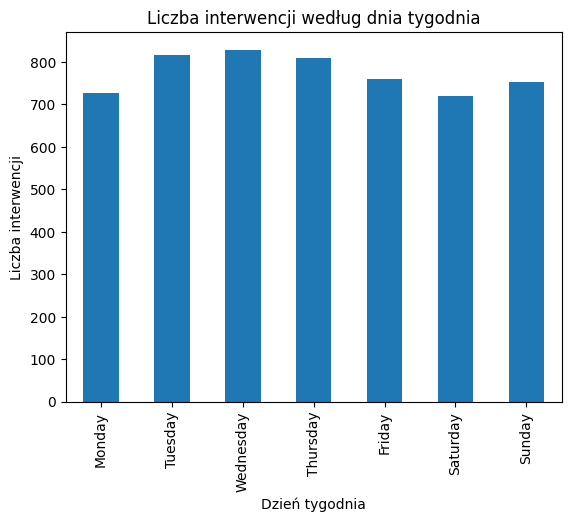

In [30]:
import matplotlib.pyplot as plt

# tworzymy wykres
counts.plot(kind='bar')

# opis wykresu
plt.title('Liczba interwencji według dnia tygodnia')
plt.xlabel('Dzień tygodnia')
plt.ylabel('Liczba interwencji')

# pokazujemy wykres
plt.show()

In [45]:
len(table_1)

1

In [35]:
table_1

[   Rank in states & territories, 2020 Rank in states & territories, 2010  \
 0                                   1                                  1   
 1                                   2                                  2   
 2                                   3                                  4   
 3                                   4                                  3   
 4                                   5                                  6   
 5                                   6                                  5   
 6                                   7                                  7   
 7                                   8                                  9   
 8                                   9                                 10   
 9                                  10                                  8   
 10                                 11                                 11   
 11                                 12                                 12   

In [69]:
url = "https://simple.wikipedia.org/wiki/List_of_U.S._states_by_population"

table_1 = pd.read_html(
    url,
    header=0,
    storage_options={"User-Agent": "Mozilla/5.0"}
)

# WYJĘCIE TABELI Z LISTY
df_pop = table_1[0]

# wyciągamy tylko potrzebne kolumny
pop = df_pop[[
    'State',
    'Census population, April 1, 2020 [1][2]'
]].copy()

# zmiana nazw 
pop.columns = ['state', 'population']

# sprawdzenie
pop.head()

,state,population
0,California,39538223
1,Texas,30145505
2,Florida,21538187
3,New York,20201249
4,Pennsylvania,13002700


In [71]:
#print(df_pop.columns.tolist())   # sprawdzenie kolumn

In [76]:
url = "https://en.wikipedia.org/wiki/List_of_U.S._state_and_territory_abbreviations"

table_2 = pd.read_html(
    url,
    header=0,
    storage_options={"User-Agent": "Mozilla/5.0"}
)

# wybór tabeli
df_pop1 = table_2[2]

# sprawdzenie
df_pop1.head()

,State,USPS Code,USCG Code
0,California,CA,CF
1,Colorado,CO,CL
2,Delaware,DE,DL
3,Hawaii,HI,HA
4,Kansas,KS,KA


In [79]:
# liczba incydentów w każdym stanie
incidents = df['state'].value_counts().reset_index()

In [80]:
df

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,day_of_week
0,3,Tim Elliot,2015-01-02,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False,Friday
1,4,Lewis Lee Lembke,2015-01-02,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False,Friday
2,5,John Paul Quintero,2015-01-03,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False,Saturday
3,8,Matthew Hoffman,2015-01-04,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False,Sunday
4,9,Michael Rodriguez,2015-01-04,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5411,5921,William Slyter,2020-06-13,shot,gun,22.0,M,W,Kansas City,MO,False,other,Other,False,Saturday
5412,5922,TK TK,2020-06-13,shot,undetermined,NaN,M,NaN,San Bernardino,CA,False,attack,Not fleeing,False,Saturday
5413,5924,Nicholas Hirsh,2020-06-15,shot,gun,31.0,M,W,Lawrence,KS,False,attack,Car,False,Monday
5414,5926,TK TK,2020-06-16,shot,gun,24.0,M,NaN,Beach Park,IL,False,attack,Not fleeing,False,Tuesday


In [81]:
# liczba incydentów w każdym stanie
incidents = df['state'].value_counts().reset_index()

In [83]:
incidents.columns = ['state', 'incidents']

In [84]:
df

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,day_of_week
0,3,Tim Elliot,2015-01-02,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False,Friday
1,4,Lewis Lee Lembke,2015-01-02,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False,Friday
2,5,John Paul Quintero,2015-01-03,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False,Saturday
3,8,Matthew Hoffman,2015-01-04,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False,Sunday
4,9,Michael Rodriguez,2015-01-04,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5411,5921,William Slyter,2020-06-13,shot,gun,22.0,M,W,Kansas City,MO,False,other,Other,False,Saturday
5412,5922,TK TK,2020-06-13,shot,undetermined,NaN,M,NaN,San Bernardino,CA,False,attack,Not fleeing,False,Saturday
5413,5924,Nicholas Hirsh,2020-06-15,shot,gun,31.0,M,W,Lawrence,KS,False,attack,Car,False,Monday
5414,5926,TK TK,2020-06-16,shot,gun,24.0,M,NaN,Beach Park,IL,False,attack,Not fleeing,False,Tuesday


In [85]:
pop_df = table_1[0]

# czyszczenie nazw kolumn (Wikipedia lubi śmieci typu [1][2])
pop_df.columns = pop_df.columns.str.replace(r"\[.*\]", "", regex=True).str.strip()

# wybór potrzebnych kolumn
pop = pop_df[['State', 'Census population, April 1, 2020']].copy()

# standaryzacja
pop.columns = ['state', 'population']

# liczby zamiast stringów
pop['population'] = pop['population'].astype(int)

In [87]:
codes_df = table_2[1]

# wybieramy tylko to co potrzebne
codes = codes_df[['Name', 'USPS Code']].copy()

# standaryzacja
codes.columns = ['state', 'abbr']


KeyError: "['USPS Code'] not in index"